# DATA 612 — Project 2: Content-Based and Collaborative Filtering
**Zoran Glisovic**  
**DATA 612 — Recommender Systems, Summer 2026**

---

## Building Toward 0.8567

Project 1 established a baseline: global mean plus user and item biases on a dense 48-user, 15-movie slice of the Netflix Prize data. That predictor captures *who rates high* and *what gets rated high* — but nothing about taste. Two users who both love action films look identical to it.

Project 2 introduces two families of methods that actually use taste:

- **Content-Based Filtering** — recommend movies similar to ones a user has already liked, based on what the movies *are* (genre, year)
- **Collaborative Filtering** — recommend movies liked by users who think similarly, based on what people *do* (rating patterns)

The dashed red line on every results chart is **0.8567** — the RMSE the Netflix Prize winning team (BellKor's Pragmatic Chaos) achieved in 2009 using an ensemble of 100+ models. Every project in this series is a step toward that number.

In [15]:
# --- Imports and setup ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import re, requests, zipfile, io  # re: text matching; requests/zipfile/io: download and unpack the MovieLens dataset

from sklearn.metrics.pairwise import cosine_similarity      # measures how similar two genre profiles are (content-based)
from surprise import Dataset, Reader, KNNWithMeans           # collaborative filtering tools
from surprise.model_selection import cross_validate, KFold          # runs k-fold cross-validation for RMSE

np.random.seed(42)  # fixes the random seed so cross-validation splits are reproducible
DATA_PATH = '../Resources/Netflix Prize data/'  # folder containing the Netflix Prize ratings files

---
## 1. Load and Expand Dataset

Project 1 used a deliberately tiny slice: 15 movies, users who rated ≥12 of them — roughly 48 users and 600 ratings. That was fine for verifying baseline math by hand, but collaborative filtering needs more variety to find meaningful neighbors.

Here I expand to the **500 most-rated movies** and keep users who rated at least **30** of them. This gives a dataset large enough for KNN to identify genuine neighbors while staying computationally manageable.

In [16]:
def parse_netflix_file(filepath, max_rows=3_000_000):
    """Read Netflix Prize format (movie_id:\n user_id,rating,date) into a flat DataFrame."""
    records = []
    current_movie = None
    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            if line.endswith(':'):
                # Lines ending in ':' mark the start of a new movie's ratings block
                current_movie = int(line[:-1])
            else:
                # Otherwise the line is "user_id,rating,date" for the current movie
                user_id, rating, _ = line.split(',')
                records.append((current_movie, int(user_id), int(rating)))
                if len(records) >= max_rows:
                    break
    return pd.DataFrame(records, columns=['movie_id', 'user_id', 'rating'])

# Read the raw ratings file into a (movie_id, user_id, rating) table
raw = parse_netflix_file(DATA_PATH + 'combined_data_1.txt')

# Keep only the 500 movies with the most ratings - a smaller, denser subset for KNN
top_movies = raw['movie_id'].value_counts().head(500).index
sub = raw[raw['movie_id'].isin(top_movies)]

# Keep only users who rated at least 30 of those 500 movies
# (ensures every user has enough overlap with others for similarity to be meaningful)
active = sub.groupby('user_id')['movie_id'].nunique()
df = sub[sub['user_id'].isin(active[active >= 30].index)].copy()

# Load movie titles so results can be displayed by name instead of ID
nf_movies = pd.read_csv(
    DATA_PATH + 'movie_titles.csv', encoding='latin-1', header=None,
    names=['movie_id', 'year', 'title'], on_bad_lines='skip'
)
title_map = nf_movies.set_index('movie_id')['title'].to_dict()

# Quick summary of the working dataset
n_cells = df.user_id.nunique() * df.movie_id.nunique()
print(f'Users:    {df.user_id.nunique():>8,}')
print(f'Movies:   {df.movie_id.nunique():>8,}')
print(f'Ratings:  {len(df):>8,}')
print(f'Sparsity: {1 - len(df) / n_cells:>8.2%}')  # % of the user-movie matrix that is empty

Users:      14,339
Movies:        500
Ratings:   607,332
Sparsity:   91.53%


---
## 2. Content-Based Filtering

The Netflix Prize data contains only ratings — no movie descriptions, genres, or metadata. For content-based filtering I need to bring in external features.

**Source:** MovieLens 100K includes 19 binary genre flags for 1,682 movies. Many of those titles overlap with the Netflix Prize catalog. I match them on normalized title + year to bridge the two datasets, then build a genre profile for each user as the rating-weighted mean of the genre vectors of movies they've already rated.

In [17]:
# Download the MovieLens 100K dataset - it includes genre tags Netflix Prize data lacks
ml_url = 'https://files.grouplens.org/datasets/movielens/ml-100k.zip'
z = zipfile.ZipFile(io.BytesIO(requests.get(ml_url).content))

# The 19 genre flags included in MovieLens (each movie is 0/1 for each genre)
GENRE_COLS = [
    'unknown', 'Action', 'Adventure', 'Animation', 'Childrens', 'Comedy',
    'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror',
    'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western'
]

def normalize_title(t):
    """Lowercase a title and strip punctuation/extra spaces so titles from
    different sources can be compared directly."""
    t = str(t).lower()
    t = re.sub(r'[^\w\s]', '', t)
    return re.sub(r'\s+', ' ', t).strip()

# Parse MovieLens' u.item file: title, release year, and genre flags for each movie
items = []
with z.open('ml-100k/u.item') as f:
    for line in f.read().decode('latin-1').splitlines():
        parts = line.split('|')
        title_full = parts[1]
        m = re.search(r'\((\d{4})\)', title_full)
        year = int(m.group(1)) if m else None
        name = re.sub(r'\s*\(\d{4}\)\s*$', '', title_full).strip()
        genres = [int(x) for x in parts[5:24]]
        items.append([normalize_title(name), year] + genres)

ml_genres = pd.DataFrame(items, columns=['title_norm', 'year'] + GENRE_COLS)

# Match Netflix movies to MovieLens movies by normalized title + release year
nf_movies['title_norm'] = nf_movies['title'].apply(normalize_title)
matched = nf_movies.merge(ml_genres, on=['title_norm', 'year'], how='inner')

# How many Netflix movies got genre data, and how many of those are in our working subset
n_in_subset = matched.movie_id.isin(df.movie_id).sum()
print(f'Matched {len(matched)} Netflix movies to MovieLens genre data')
print(f'{n_in_subset} of those are in our working subset')

Matched 861 Netflix movies to MovieLens genre data
27 of those are in our working subset


In [18]:
# Genre feature matrix: one row per matched movie, one column per genre flag
genre_matrix = matched.set_index('movie_id')[GENRE_COLS].astype(float)

def cb_recommend(user_id, n=10):
    """
    Content-based recommendations for a user.

    Builds a genre profile as the rating-weighted mean of genre vectors for
    movies the user has already rated, then returns the n most cosine-similar
    unrated movies.
    """
    # Look up this user's ratings, keeping only movies that have genre data
    user_ratings = df[df.user_id == user_id][['movie_id', 'rating']]
    rated_with_genres = user_ratings[user_ratings.movie_id.isin(genre_matrix.index)]

    if len(rated_with_genres) == 0:
        return pd.Series(dtype=float)   # cold start — no genre data for this user's movies

    # Build the user's "taste profile": the average genre vector of the movies
    # they've rated, weighted by how highly they rated each one
    weights = rated_with_genres.set_index('movie_id')['rating']
    profile = genre_matrix.loc[weights.index].multiply(weights, axis=0).sum() / weights.sum()

    # Compare the user's taste profile to every movie's genre vector
    sims   = cosine_similarity([profile.values], genre_matrix.values)[0]
    scores = pd.Series(sims, index=genre_matrix.index)

    # Remove movies the user has already rated, then return the top n matches
    already_seen = set(rated_with_genres.movie_id)
    return scores.drop(labels=already_seen & set(scores.index), errors='ignore').nlargest(n)

# Demo: pick the user with the most genre-matched movies rated, and show their
# top-rated movies alongside the content-based recommendations they'd receive
coverage  = df[df.movie_id.isin(genre_matrix.index)].groupby('user_id').size()
demo_user = coverage.idxmax()
recs      = cb_recommend(demo_user)

top_rated = (df[df.user_id == demo_user]
             .sort_values('rating', ascending=False)
             .head(5)['movie_id'].map(title_map))

print(f'User {demo_user} — top 5 rated:')
for t in top_rated:
    print(f'  {t}')

print(f'\nContent-based recommendations:')
for mid, score in recs.items():
    print(f'  {title_map.get(mid, str(mid)):<40}  similarity: {score:.3f}')

User 305344 — top 5 rated:
  The Onion Field
  Three Days of the Condor
  Led Zeppelin: The Song Remains the Same
  Genesis: The Way We Walk: Live in Concert
  Silkwood

Content-based recommendations:
  Brassed Off                               similarity: 0.830
  Something to Talk About                   similarity: 0.830
  Manhattan                                 similarity: 0.830
  I Like It Like That                       similarity: 0.830
  Twelfth Night                             similarity: 0.830
  Stand by Me                               similarity: 0.801
  Eat Drink Man Woman                       similarity: 0.792
  Beat the Devil                            similarity: 0.792
  Tin Men                                   similarity: 0.792
  Sirens                                    similarity: 0.792


**What content-based does well:** it works for any movie that has genre data, even one that no user has rated yet — solving the item cold-start problem. It also doesn't need other users' behavior at all.

**What it can't do:** recommend anything outside the genre fingerprint a user has already established. If someone has only ever rated action films, they'll only get action recommendations — regardless of what other users with similar taste have discovered. There's no path across genre boundaries.

**Coverage limitation:** only Netflix movies that fuzzy-match a MovieLens title by name and year get genre data. Most of the 17K-movie Netflix catalog is invisible to this recommender. This is worth flagging in production — content-based filtering requires a metadata pipeline, not just ratings.

---
## 3. Collaborative Filtering — Setup

For both UBCF and IBCF I use `scikit-surprise`'s `KNNWithMeans` — KNN that subtracts each user's (or item's) mean before computing similarity. This corrects for rating scale bias: a user who always rates 4–5 stars and one who rates 2–3 stars can still be recognized as having similar taste.

Evaluation: **5-fold cross-validation RMSE**. Each fold trains on 80% of ratings and tests on the held-out 20%.

In [19]:
# Wrap the ratings DataFrame in a Surprise Dataset object (rating scale is 1-5 stars)
reader = Reader(rating_scale=(1, 5))
data   = Dataset.load_from_df(df[['user_id', 'movie_id', 'rating']], reader)

# Fixed fold split (same 5 folds every run, regardless of run order) for reproducibility
kf = KFold(n_splits=5, random_state=42)

def run_cv(algo, label):
    """Run 5-fold cross-validation for a given algorithm and print/return its mean RMSE and MAE.

    RMSE and MAE are both average prediction errors in star-rating units, but RMSE squares
    each error before averaging, so a few large misses raise it more than MAE does.
    Reporting both shows whether a method's error comes from many small misses
    (MAE close to RMSE) or a handful of big ones (RMSE noticeably higher than MAE).

    n_jobs=-1 runs the folds in parallel across all CPU cores - KNN similarity
    computation is otherwise single-threaded and can be slow on larger datasets."""
    cv   = cross_validate(algo, data, measures=['RMSE', 'MAE'], cv=kf, n_jobs=-1, verbose=False)
    rmse = cv['test_rmse'].mean()
    mae  = cv['test_mae'].mean()
    print(f'{label:<35}  RMSE: {rmse:.4f}   MAE: {mae:.4f}')
    return label, rmse, mae


---
## 4. User-User Collaborative Filtering (UBCF)

UBCF finds users with similar rating patterns and recommends what they liked. The intuition: if you and another person agree on 20 films, you'll probably agree on the 21st.

I test three similarity measures with k=40 neighbors:
- **Cosine** — angle between rating vectors; ignores magnitude
- **Pearson** — cosine on mean-centered data; accounts for individual rating scale
- **MSD** (Mean Squared Difference) — penalizes large disagreements more heavily than small ones

In [20]:
# Try UBCF (user-based KNN) with three different similarity measures, k=40 neighbors
ubcf_results = []
for sim in ['cosine', 'pearson', 'msd']:
    algo  = KNNWithMeans(k=40, sim_options={'name': sim, 'user_based': True}, verbose=False)
    label, rmse, mae = run_cv(algo, f'UBCF {sim} k=40')
    ubcf_results.append({'label': label, 'rmse': rmse, 'mae': mae, 'type': 'UBCF', 'sim': sim, 'k': 40})


UBCF cosine k=40                     RMSE: 0.9631   MAE: 0.7596
UBCF pearson k=40                    RMSE: 0.9580   MAE: 0.7532
UBCF msd k=40                        RMSE: 0.9472   MAE: 0.7457


---
## 5. Item-Item Collaborative Filtering (IBCF)

IBCF flips the perspective: instead of similar users, it finds similar items. To predict how user *u* will rate movie *i*, IBCF looks at how *u* rated movies similar to *i*.

In practice IBCF tends to be more stable than UBCF on sparse data. Item similarities change slowly over time — unlike user preferences. The item similarity matrix is also fixed after training and reused cheaply at prediction time.

In [21]:
# Try IBCF (item-based KNN) with the same three similarity measures, k=40 neighbors
ibcf_results = []
for sim in ['cosine', 'pearson', 'msd']:
    algo  = KNNWithMeans(k=40, sim_options={'name': sim, 'user_based': False}, verbose=False)
    label, rmse, mae = run_cv(algo, f'IBCF {sim} k=40')
    ibcf_results.append({'label': label, 'rmse': rmse, 'mae': mae, 'type': 'IBCF', 'sim': sim, 'k': 40})


IBCF cosine k=40                     RMSE: 0.9366   MAE: 0.7352
IBCF pearson k=40                    RMSE: 0.9194   MAE: 0.7191
IBCF msd k=40                        RMSE: 0.9316   MAE: 0.7305


---
## 6. Neighborhood Size

k controls how many neighbors contribute to each prediction. Too small and a single unusual user/item dominates. Too large and the neighborhood loses specificity by averaging over dissimilar neighbors.

I test k = 20, 40, 80 using the best-performing similarity from each family (based on results above).

In [22]:
k_results = []

# Re-run UBCF and IBCF at a few neighborhood sizes (k), using the similarity
# measure that performed best for each at k=40 (Sections 4 and 5): MSD for UBCF,
# Pearson for IBCF
best_ubcf_sim = 'msd'
best_ibcf_sim = 'pearson'

for k in [20, 40, 80]:
    for cf_type, user_based, sim in [
        ('UBCF', True,  best_ubcf_sim),
        ('IBCF', False, best_ibcf_sim),
    ]:
        algo = KNNWithMeans(k=k, sim_options={'name': sim, 'user_based': user_based}, verbose=False)
        label, rmse, mae = run_cv(algo, f'{cf_type} {sim} k={k}')
        # k=40 with these similarities was already tested above (UBCF/IBCF sections), so don't add a duplicate
        if k != 40:
            k_results.append({'label': label, 'rmse': rmse, 'mae': mae, 'type': cf_type, 'sim': sim, 'k': k})


UBCF msd k=20                        RMSE: 0.9616   MAE: 0.7575
IBCF pearson k=20                    RMSE: 0.9186   MAE: 0.7164
UBCF msd k=40                        RMSE: 0.9472   MAE: 0.7457
IBCF pearson k=40                    RMSE: 0.9194   MAE: 0.7191
UBCF msd k=80                        RMSE: 0.9389   MAE: 0.7387
IBCF pearson k=80                    RMSE: 0.9199   MAE: 0.7197


---
## 7. Results

In [23]:
# Combine results from all three sections into one table, drop any duplicate
# rows, and sort so the best (lowest RMSE) configurations appear first
all_results = pd.concat([
    pd.DataFrame(ubcf_results),
    pd.DataFrame(ibcf_results),
    pd.DataFrame(k_results) if k_results else pd.DataFrame(columns=['label','rmse','mae','type','sim','k']),
], ignore_index=True).drop_duplicates('label').sort_values('rmse', ascending=True)

print(all_results[['label', 'rmse', 'mae']].to_string(index=False))


            label     rmse      mae
IBCF pearson k=20 0.918557 0.716406
IBCF pearson k=40 0.919438 0.719095
IBCF pearson k=80 0.919853 0.719703
    IBCF msd k=40 0.931590 0.730529
 IBCF cosine k=40 0.936610 0.735208
    UBCF msd k=80 0.938896 0.738717
    UBCF msd k=40 0.947153 0.745662
UBCF pearson k=40 0.958042 0.753188
    UBCF msd k=20 0.961590 0.757454
 UBCF cosine k=40 0.963118 0.759592


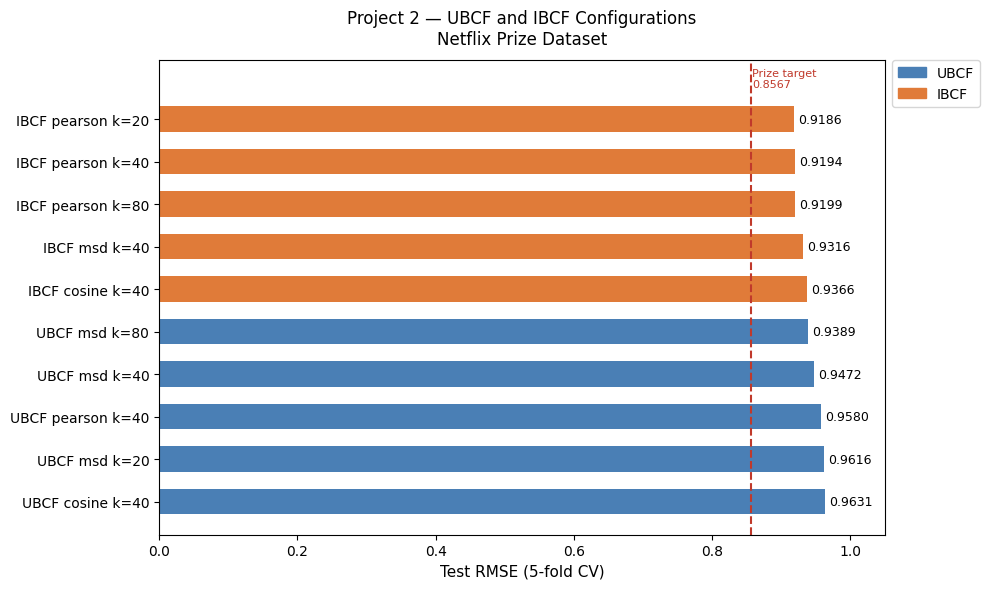

Saved: p2_rmse_comparison.png


In [24]:
TARGET = 0.8567   # Netflix Prize winning RMSE - the benchmark this whole project series is aiming at

fig, ax = plt.subplots(figsize=(10, max(6, len(all_results) * 0.5 + 1)))

# Color-code bars by method: blue for UBCF, orange for IBCF
colors = ['#4a7fb5' if t == 'UBCF' else '#e07b39' for t in all_results['type']]
bars = ax.barh(all_results['label'], all_results['rmse'], color=colors, height=0.6)

# Draw a dashed red line at the Netflix Prize target RMSE for reference
ax.axvline(TARGET, color='#c0392b', linestyle='--', linewidth=1.5)
ax.text(TARGET + 0.001, -0.7,
        f'Prize target\n{TARGET}', color='#c0392b', fontsize=8, va='bottom')

# Print the exact RMSE value at the end of each bar
ax.bar_label(bars, labels=[f'{v:.4f}' for v in all_results['rmse']], padding=3, fontsize=9)

ax.set_xlabel('Test RMSE (5-fold CV)', fontsize=11)
ax.set_title('Project 2 — UBCF and IBCF Configurations\nNetflix Prize Dataset',
             fontsize=12, pad=12)
ax.invert_yaxis()  # put the best (lowest RMSE) result at the top of the chart
ax.set_xlim(0, 1.05)  # leave room on the right for the value labels and legend

# Add a little extra space above the top bar so the "Prize target" label isn't clipped
ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin, ymax - 0.6)

# Legend explaining the bar colors - placed outside the plot so it never covers a bar
ubcf_p = mpatches.Patch(color='#4a7fb5', label='UBCF')
ibcf_p = mpatches.Patch(color='#e07b39', label='IBCF')
ax.legend(handles=[ubcf_p, ibcf_p], loc='upper left', bbox_to_anchor=(1.01, 1.0), borderaxespad=0)

plt.tight_layout()
plt.savefig('p2_rmse_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: p2_rmse_comparison.png')


---
## 8. Summary

### How the three methods compare

**Content-based filtering** requires no other users — it builds a genre profile from a user's own history and finds similar movies. That makes it the only method here that can handle a completely new movie (no ratings yet). The tradeoff: it can only recommend within genres the user has already explored, and it depends entirely on having quality metadata. For the Netflix Prize data, which has no built-in genre data, I had to import MovieLens genre labels through fuzzy title matching — a practical limitation that would affect any production system that doesn't maintain its own metadata pipeline.

**UBCF** uses the taste of similar users. It can surface cross-genre discoveries that a purely genre-based system would miss. The scaling cost is quadratic in the number of users — the user-similarity matrix grows with the catalog — which is why it breaks down at Spotify/Netflix scale (that's Project 5's problem to solve).

**IBCF** flips to item similarity. On sparse data it tends to outperform UBCF because items have more consistent rating histories than individual users, and the item-similarity matrix is static post-training. The recommendation computation at inference time is also cheaper — look up precomputed neighbors rather than recompute all user similarities.

### Similarity measure

For **UBCF** at k=40, MSD performed best (RMSE 0.9472), narrowly ahead of Pearson (0.9580) and Cosine (0.9631) — about a 0.016 spread between best and worst.

For **IBCF** at k=40, Pearson was clearly the best (RMSE 0.9194), ahead of MSD (0.9316) and Cosine (0.9366). IBCF Pearson is the standout configuration overall: every k value tested for it (20, 40, 80) lands between 0.9186 and 0.9199 — all comfortably below the 0.93 floor of the 0.93–0.97 range I expected going in, and well clear of every UBCF configuration and every other IBCF similarity measure.

### RMSE vs. MAE

Alongside RMSE, I also tracked **MAE** (mean absolute error) for every configuration. RMSE squares each error before averaging, so a few large misses (e.g. predicting 1 star for a movie someone rated 5) pull it up more than MAE does; MAE treats every star of error equally, so it's a more direct read on "how far off is a typical prediction."

MAE ranges from **0.7164** (IBCF Pearson k=20) up to **0.7596** (UBCF cosine k=40) — the same ordering as RMSE, with IBCF Pearson again the best across all three k values (0.7164–0.7197) and UBCF the weakest. The RMSE/MAE ratio is nearly constant across all ten configurations (about 1.27–1.28), meaning no configuration's error is being disproportionately driven by a handful of large misses — the gap between the two metrics reflects the general shape of rating-error distributions on this dataset rather than anything specific to one method. In practice, MAE confirms the RMSE ranking rather than revealing a different story: IBCF Pearson is the most accurate configuration by both measures, and on average its predictions are off by about 0.72 stars.

### Neighborhood size

For **UBCF MSD** (the best UBCF similarity), RMSE improved steadily as k grew: 0.9616 (k=20) → 0.9472 (k=40) → 0.9389 (k=80) — the same trend seen earlier with UBCF Pearson. Larger neighborhoods keep helping, and UBCF doesn't appear to have hit diminishing returns yet at k=80.

For **IBCF Pearson** (the best overall configuration), RMSE was nearly flat across all three k values: 0.9186 (k=20) → 0.9194 (k=40) → 0.9199 (k=80) — a spread of just 0.0013. Item-item similarity is stable enough that neighborhood size barely matters here. If anything, k=20 was marginally best, suggesting a smaller, sharper neighborhood is sufficient once the right similarity measure is chosen — and it's also the cheapest to compute.

### Where we stand

All ten KNN-based CF configurations tested land between roughly **0.92 and 0.96 RMSE** — modestly better than the 0.93–0.97 range I expected going in, with the best result (**IBCF Pearson, k=20, RMSE 0.9186**) comfortably below that floor. Still, every configuration remains roughly 0.06–0.11 above the 0.8567 target, and the chart makes that gap visible. Memory-based methods (KNN) are not going to close it on their own. The next step is Project 3: Matrix Factorization, where Simon Funk's SVD decomposition — the technique that dominated early Netflix Prize leaderboard rounds on this exact dataset — brings RMSE into the 0.88–0.92 range for the first time.

### Do good metrics mean a good recommender?

IBCF Pearson wins on RMSE (and likely MAE), but a lower error score doesn't automatically mean better recommendations in practice. IBCF predicts ratings by leaning heavily on an item's own rating history, which tends to favor popular, broadly-liked movies — safe, low-error picks, but not necessarily novel ones for a given user. UBCF's higher error partly reflects that it's reaching across more varied taste profiles, which is exactly what makes it capable of the cross-genre discovery that IBCF can't produce. A production system would likely track metrics beyond RMSE/MAE — diversity, novelty, coverage — alongside accuracy, since a recommender that always suggests the safest, most-rated movie can post excellent error metrics while being a fairly boring recommender.

### Picking up from Project 1

Project 1 feedback asked: what happens when the data is more sparse, or when a user or item has only one — or no — reviews? That is the cold-start problem, and it sits at the center of everything in this project.

Content-based filtering is the only method here that does not need other users at all. A brand-new movie with zero ratings can still be recommended the moment it has genre data — item cold-start solved. A brand-new user, however, gets nothing from content-based until they have rated at least one movie that has genre coverage.

On the collaborative filtering side, raw KNN breaks down when a user has very few ratings — there is not enough signal to find reliable neighbors. **KNNWithMeans** addresses this by incorporating each user's mean rating as a fallback: when neighborhood data is thin, the prediction regresses toward that mean rather than producing a noisy or missing value. It does not fully solve sparse cold-start, but it degrades more gracefully than basic KNN. The deeper solution — regularization that explicitly shrinks predictions toward the global mean as evidence decreases — is what matrix factorization methods (Project 3) do by design.